In [44]:
import importlib.util
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import preprocessing
from pydmd import DMD, MrDMD
from sklearn.preprocessing import StandardScaler
import seaborn as sns
custom_rqa_path = Path("/home/idies/workspace/RQA-and-mrDMD") / "CustomRQA.py"
spec = importlib.util.spec_from_file_location("CustomRQA", str(custom_rqa_path))

CustomRQA = importlib.util.module_from_spec(spec)

spec.loader.exec_module(CustomRQA)

sys.modules["CustomRQA"] = CustomRQA


truncate_path = Path("/home/idies/workspace/RQA-and-mrDMD") / "truncate.py"

spec = importlib.util.spec_from_file_location("truncate", str(truncate_path))

truncate = importlib.util.module_from_spec(spec)

spec.loader.exec_module(truncate)

sys.modules["truncate"] = truncate

import CustomRQA as rqa
import truncate as tr
import warnings 
warnings.filterwarnings('ignore')


(540, 20000)


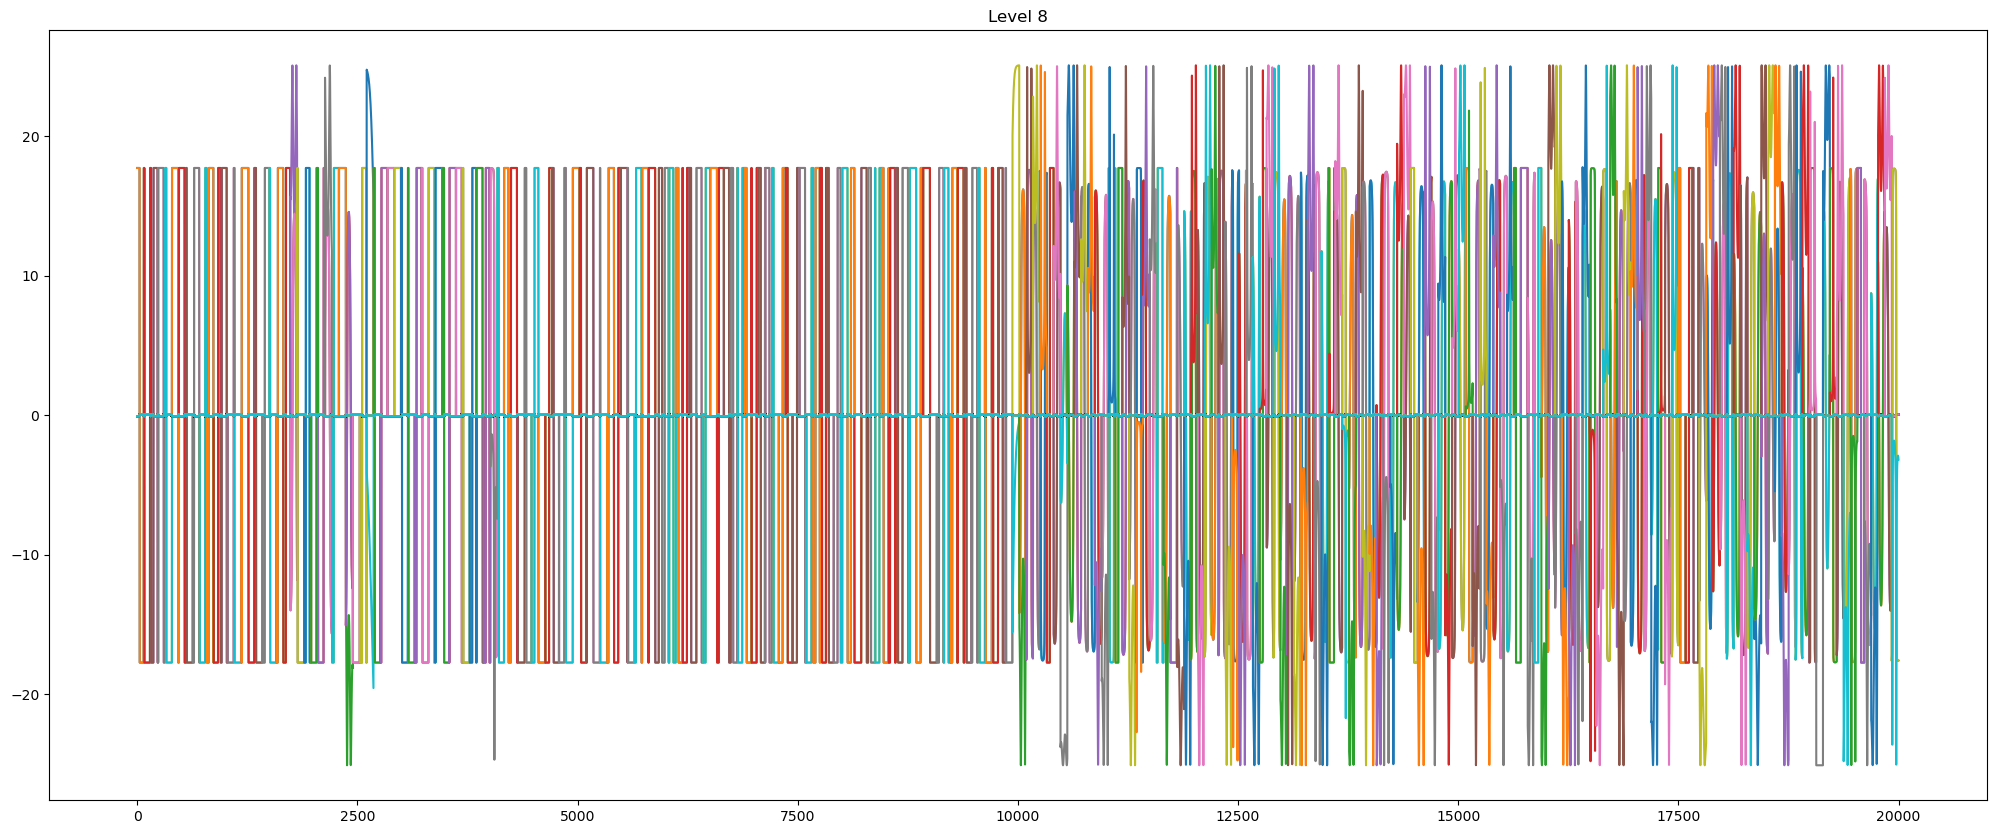

(630, 20000)
(20000, 376)


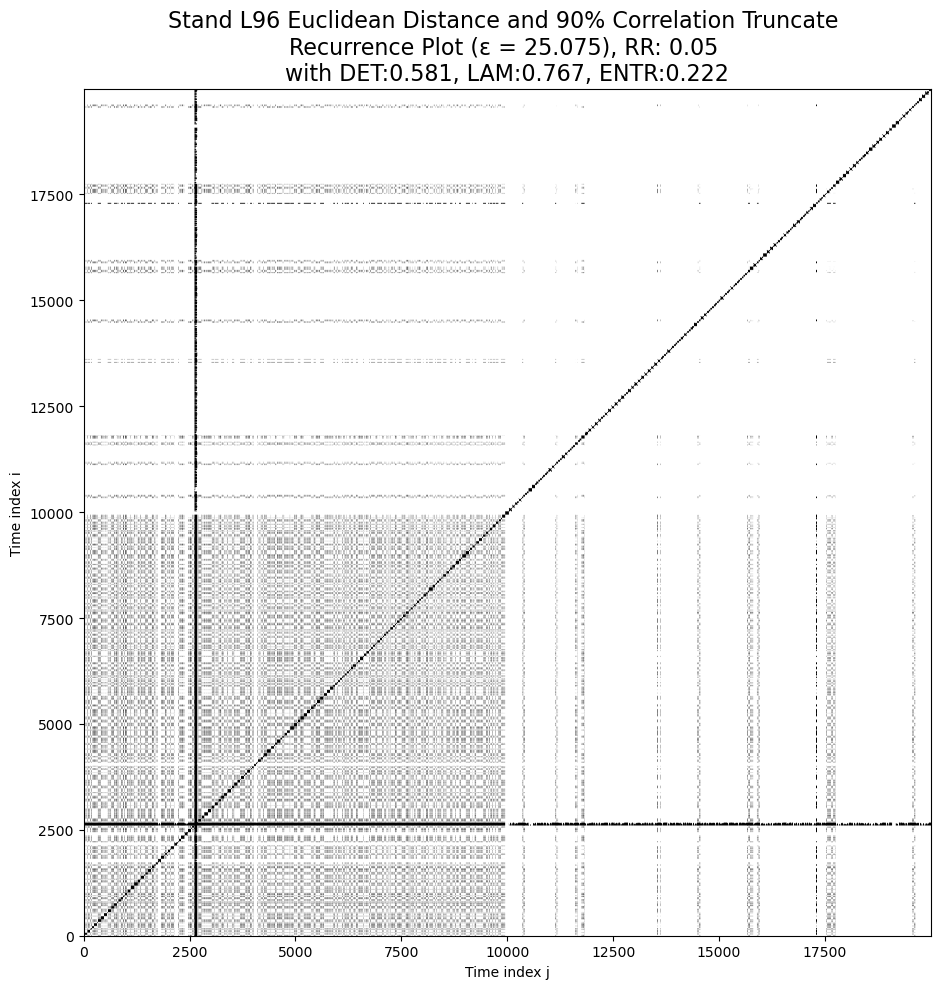

In [45]:
url = '/home/idies/workspace/RQA-and-mrDMD/Lorenz96/final_L96.npy'
X = np.load(url)
print(X.shape)
sub_dmd = DMD(svd_rank=0.75)
l=8
mrdmd = MrDMD(sub_dmd, max_level=l, max_cycles=1)
mrdmd.fit(X)
last_dynamics = mrdmd.partial_dynamics(level=l)
last_dynamics = StandardScaler().fit_transform(last_dynamics.real)
plt.figure(figsize=(25,10))
for i in range(last_dynamics.shape[0]):
    plt.plot(last_dynamics[i])
plt.title(f'Level 8')
plt.show()


print(last_dynamics.shape)
df_dynamics = tr.correlation_truncate(last_dynamics.T, threshold =0.80)
all_vectors_new = df_dynamics.to_numpy()
all_vectors = all_vectors_new
print(all_vectors_new.shape)

all_vectors = all_vectors_new
p=5
metrics = rqa.RecurrencePlot(all_vectors, percent=p, metric ='euclidean', plot = True, globalEpsilon=True, Title = 'Stand L96 Euclidean Distance and 90% Correlation Truncate',lines = False)




In [46]:
print(X.shape)

(540, 20000)


In [48]:

p=5
total_time = X.shape[1]
window_size= .1 * total_time
one_side = window_size//2
times, det_ts, lam_ts, entr_ts = [], [], [], []
sub_dmd = DMD(svd_rank=0.75)
l=8
mrdmd = MrDMD(sub_dmd, max_level=l, max_cycles=1)
for t in range(int(one_side) , int(total_time - one_side),1000):
    block_X = X[:, int(t - one_side) : int(t + one_side) ]
    mrdmd.fit(block_X)
    print(block_X.shape)
    last_dynamics = mrdmd.partial_dynamics(level=l)
    last_dynamics = StandardScaler().fit_transform(last_dynamics.real)
    print(last_dynamics.T.shape)
    df_dynamics = tr.correlation_truncate(last_dynamics.T, threshold =0.80)
    all_vectors_new = df_dynamics.to_numpy()
    print(all_vectors_new.shape)
    metrics,_ = rqa.RecurrencePlot(all_vectors_new, percent=p, globalEpsilon=True, plot=False)
    det_ts.append(metrics['DET'])
    lam_ts.append(metrics['LAM'])
    entr_ts.append(metrics['ENTR'])  
    times.append(t)
    print('\n\n\n')
times = np.array(times)
DETS = det_ts
LAMS= lam_ts
ENTRS = entr_ts

print(times)

(540, 2000)
(2000, 257)
(2000, 248)




(540, 2000)
(2000, 260)
(2000, 248)




(540, 2000)
(2000, 261)
(2000, 248)




(540, 2000)
(2000, 258)
(2000, 251)




(540, 2000)
(2000, 260)
(2000, 246)




(540, 2000)
(2000, 260)
(2000, 247)




(540, 2000)
(2000, 258)
(2000, 250)




(540, 2000)
(2000, 261)
(2000, 247)




(540, 2000)
(2000, 255)
(2000, 246)




(540, 2000)
(2000, 273)
(2000, 250)




(540, 2000)
(2000, 291)
(2000, 255)




(540, 2000)
(2000, 290)
(2000, 256)




(540, 2000)
(2000, 287)
(2000, 250)




(540, 2000)
(2000, 297)
(2000, 258)




(540, 2000)
(2000, 294)
(2000, 258)




(540, 2000)
(2000, 289)
(2000, 258)




(540, 2000)
(2000, 291)
(2000, 257)




(540, 2000)
(2000, 283)
(2000, 249)




[ 1000  2000  3000  4000  5000  6000  7000  8000  9000 10000 11000 12000
 13000 14000 15000 16000 17000 18000]


In [49]:
print((ENTRS))
'''
from scipy.signal import savgol_filter
DETS = savgol_filter(DETS, window_size//2, 2)
ENTRS = savgol_filter(ENTRS, window_size//2, 2)
LAMS = savgol_filter(LAMS, window_size//2, 2)
'''


[0.5459287015042097, 0.527021560073118, 0.5315632680086985, 0.5502441398885245, 0.5161749939416038, 0.5153597108862897, 0.516046929854564, 0.5143245156790441, 0.5222580377814743, 0.5008561616169556, 0.6415387849468213, 0.6162836490968048, 0.6029986948239509, 0.6323695682442007, 0.5754301822622141, 0.5764773800178173, 0.5833447847526173, 0.6092084633128716]


'\nfrom scipy.signal import savgol_filter\nDETS = savgol_filter(DETS, window_size//2, 2)\nENTRS = savgol_filter(ENTRS, window_size//2, 2)\nLAMS = savgol_filter(LAMS, window_size//2, 2)\n'

In [50]:
# real‑time axes
x=X
total_time = 200
real_times = (times - times.min()) / (times.max() - times.min()) * total_time

time_axis = np.linspace(0, total_time, x.shape[0])

regime_times_real = np.array([100.0])
window_real = window_size * (total_time / (x.shape[0] - 1))

print(regime_times_real)
print(window_real)



[100.]
742.1150278293135


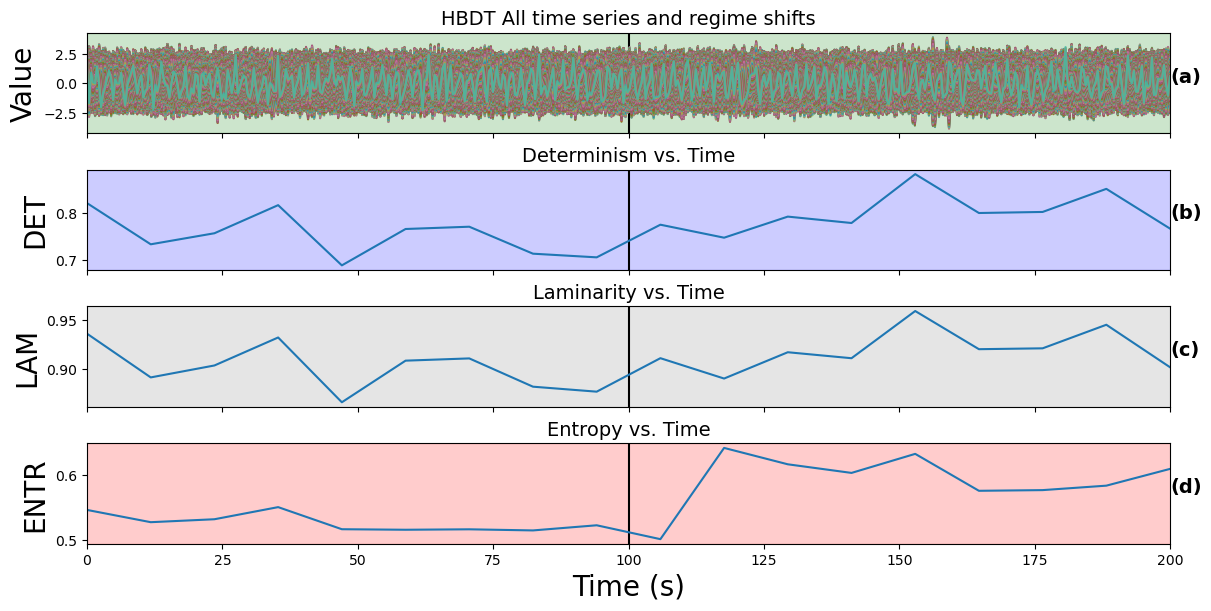

In [51]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)

labels = ['(a)', '(b)', '(c)', '(d)']
regime_kwargs = dict(color='black', linestyle='solid')
i = 0 
colors = ['green', 'blue', 'gray', 'red', 'yellow']
for ax in axes:
    for t_real in regime_times_real:
        ax.axvline(t_real, **regime_kwargs)
        ax.axvspan(t_real - window_real/2, t_real + window_real/2, color=colors[i], alpha=0.2)
        i = (i+1)%5

axes[0].plot(time_axis, x, alpha=0.6)  
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series and regime shifts', fontsize=14)

axes[1].plot(real_times, DETS)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism vs. Time', fontsize=14)

axes[2].plot(real_times, LAMS)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity vs. Time', fontsize=14)

axes[3].plot(real_times, ENTRS)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy vs. Time', fontsize=14)
axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(0, total_time)

for ax, label in zip(axes, labels):
    ax.text(1, 0.51, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold')

plt.show()


In [6]:

def l96(x,t, F, alpha=1):
  return (np.roll(x, -1) - np.roll(x, 2)) * np.roll(x, 1) - alpha* x + F
total_time = 120
m = 1200
dt = total_time/m
t1 = np.arange(0.0,total_time, dt)
n=540
F_1 = 5
x0 = F_1 * np.ones(n)
x0[0] += 0.01
alpha1=1
regime1 = odeint(l96, x0, t1, args=(F_1, alpha1))
regime1 = regime1[200:]
t1 = t1[200:]
total_time = 200
m = 2000
dt = total_time/m
t2 = np.arange(0.0,total_time, dt)
F_2 = 16
x0 = F_2 * np.ones(n)
x0[0] += 0.01
alpha2= 1.5
regime2 = odeint(l96, x0, t2, args=(F_2, alpha2))
regime2 = regime2[1000:]
t2 = t2[1000:]
t1_adj = (t1 - 20)     
t2_adj = t2     

t = np.concatenate([t1_adj, t2_adj])              
X = np.vstack([regime1, regime2])              
X = StandardScaler().fit_transform(X)
print(X.shape)

NameError: name 'odeint' is not defined

In [60]:
import random
import numpy as np
import random

def get_metrics(x,n, window=.1,p=10):
    sampled_dets = []
    sampled_lams = []
    sampled_entr = []
    sampled_ratio = []
    window_size = window * x.shape[0]
    start = window_size//2
    end = x.shape[0]-window_size//2
    # print(start, end)
    for i in range(0,n):
        random_number = random.randint(start, end)
        block = x[int(random_number-window_size//2): int(random_number+window_size//2)]
        metrics,_ = rqa.RecurrencePlot(block, percent=p, metric ='euclidean', globalEpsilon=True)
        det = metrics['DET']
        lam = metrics['LAM']
        entr = metrics['ENTR']
        sampled_dets.append(det)
        sampled_lams.append(lam)
        sampled_entr.append(entr)
    return sampled_dets, sampled_lams, sampled_entr
print(X)
sampled_dets, sampled_lams, sampled_entr = get_metrics(X,1000, window=.2)


[[-1.1057365  -0.39990518 -0.19190474 ... -0.29388605  0.26566717
  -0.08594086]
 [-1.04184764 -0.32664732  0.04525512 ... -0.32039354  0.23931119
  -0.2905449 ]
 [-0.93573748 -0.31428496  0.26244188 ... -0.38755975  0.19029981
  -0.42007513]
 ...
 [ 0.59827384  0.85776138  0.23373293 ... -0.44632194  0.59036865
   1.14552763]
 [ 0.66065797  0.34801519 -0.29611735 ...  0.84782097  1.16059244
   1.4874821 ]
 [-0.11983995  0.11470986 -0.21534157 ...  1.62217637  2.25120525
   0.51568811]]
200.0 1800.0


In [ ]:
def bootstrap_ci(sampled_metric,n,alpha=0.05,plot=False, metric_name=''):
    if plot:
        plt.figure(figsize=(8, 5))
        sns.histplot(sampled_metric, bins=len(sampled_metric)//10, kde=True, stat="density", color="skyblue", edgecolor="black")
        plt.title(f"Distribution of {metric_name} ")
        plt.xlabel("Value")
        plt.ylabel("Density")
        plt.show()
    print(np.min(sampled_metric), np.max(sampled_metric))
    print(100*alpha/2, 100*(1-alpha/2))
    lo, hi = np.percentile(sampled_metric, [100*alpha/2, 100*(1-alpha/2)])
    print(lo,hi)
    return lo,hi
alpha=0.1
bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
# Overl a 

0.3817757866822883 0.9902560937610226
5.0 95.0
0.4522477661812899 0.7623256399308406


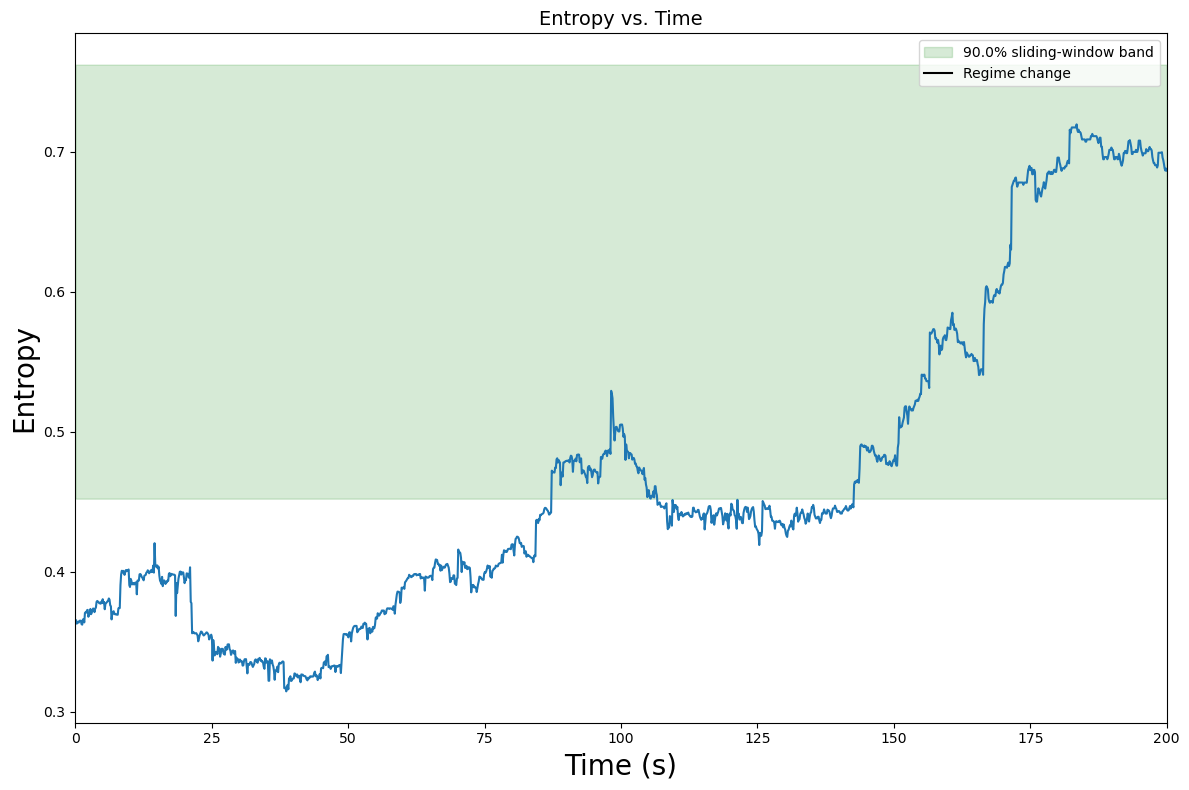

986
0.1
0.8167948717948718 0.9998717948717949
5.0 95.0
0.8490961538461539 0.995


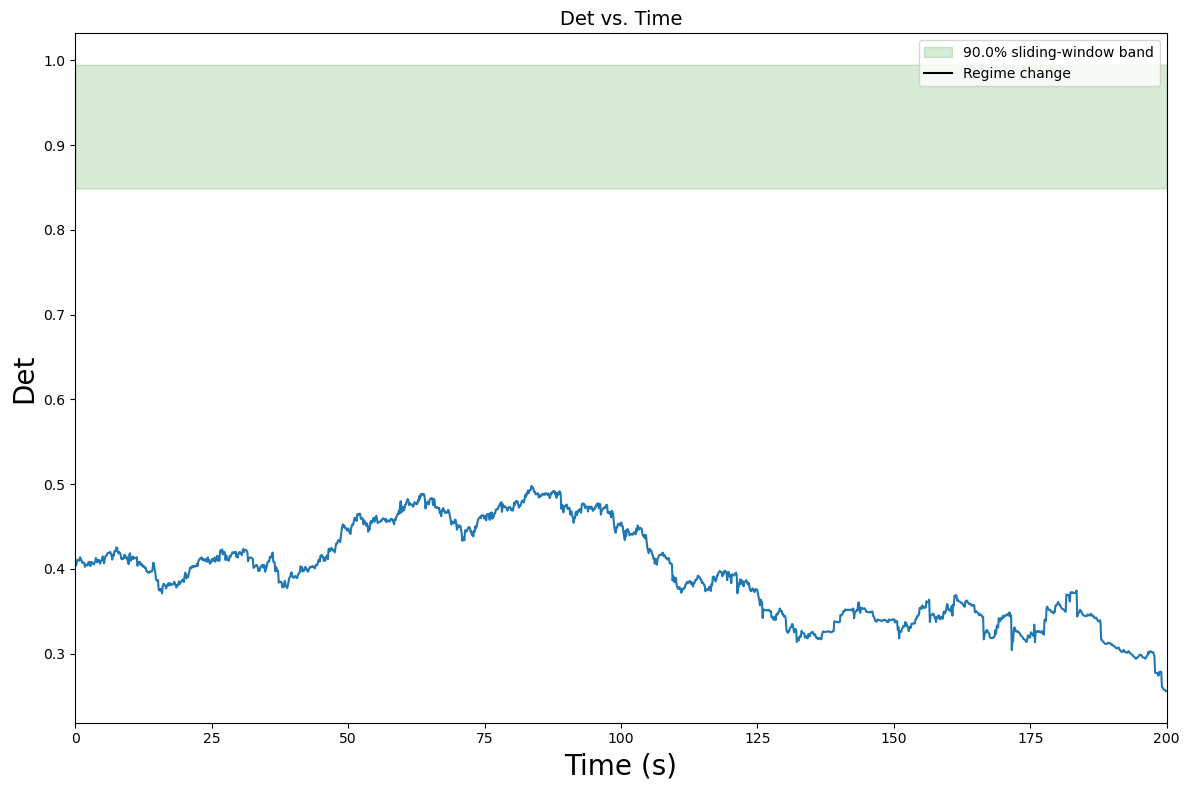

0.8732692307692308 0.9959615384615385
5.0 95.0
0.8869230769230769 0.9902564102564102


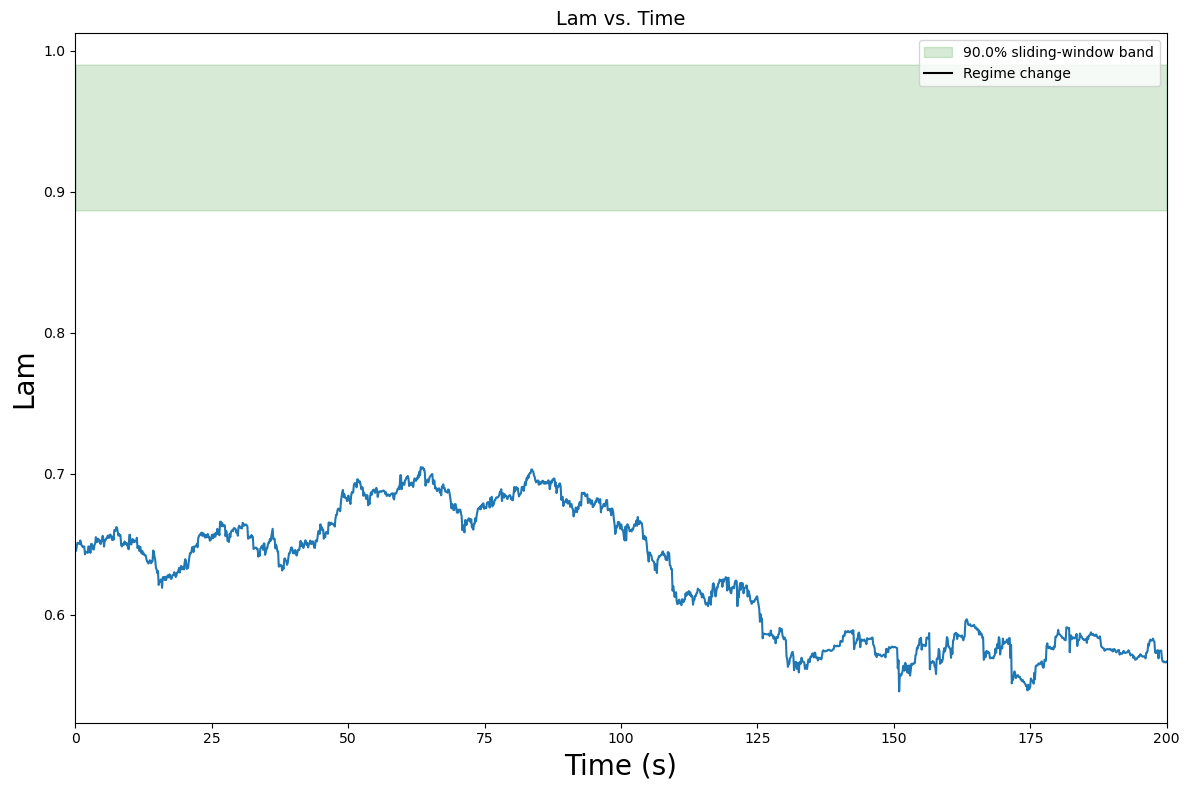

In [51]:
def plotting(metric, metric_name, lo,hi, percent):
    plt.figure(figsize=(12,8))
    plt.plot(real_times, metric)
    plt.ylabel(f'{metric_name}', fontsize=20)
    plt.title(f'{metric_name} vs. Time', fontsize=14)
    plt.xlabel('Time (s)', fontsize=20)
    plt.xlim(0, total_time)
    plt.fill_between(real_times, lo, hi, alpha=0.16, label=f'{100-percent}% sliding-window band', zorder=1, color='green')
    plt.axvline(1000, color='black', linestyle='solid', label='Regime change')
    plt.tight_layout()
    plt.legend()
    plt.show()
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=False,metric_name='Entropy')
plotting(ENTRS, 'Entropy', lo,hi, alpha*100)
print(sum(ENTRS < lo))
print(alpha)
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=False,metric_name='')
plotting(DETS, 'Det', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=False,metric_name='')
plotting(LAMS, 'Lam', lo,hi, alpha*100)

In [22]:
import random

def get_metrics(x,n, window=.2,p=10):
    sampled_dets = []
    sampled_lams = []
    sampled_entr = []
    window_size = window * x.shape[0]
    start = window_size//2
    end = x.shape[0]-window_size//2
    for i in range(0,n):
        random_number = random.randint(start, end)
        block = x[int(random_number-window_size//2): int(random_number+window_size//2)]
        metrics,_ = rqa.RecurrencePlot(block, percent=p, metric ='euclidean', globalEpsilon=True)
        det = metrics['DET']
        lam = metrics['LAM']
        entr = metrics['ENTR']
        sampled_dets.append(det)
        sampled_lams.append(lam)
        sampled_entr.append(entr)
    return sampled_dets, sampled_lams, sampled_entr
def bootstrap_ci(sampled_metric,n,alpha=0.05,plot=False, metric_name=''):
    if plot:
        plt.figure(figsize=(8, 5))
        sns.histplot(sampled_metric, bins=len(sampled_metric)//100, kde=True, stat="density", color="skyblue", edgecolor="black")
        plt.title(f"Distribution of {metric_name} ")
        plt.xlabel("Value")
        plt.ylabel("Density")
        plt.show()
    lo, hi = np.percentile(sampled_metric, [100*alpha/2, 100*(1-alpha/2)])
    print(lo,hi)
    return lo,hi

def plotting(metric, metric_name, lo,hi, percent):
    plt.figure(figsize=(12,8))
    plt.plot(real_times, metric)
    plt.ylabel(f'{metric_name}', fontsize=20)
    plt.title(f'{metric_name} vs. Time', fontsize=14)
    plt.xlabel('Time (s)', fontsize=20)
    plt.xlim(0, total_time)
    plt.fill_between(real_times, lo, hi, alpha=0.36, label=f'{100-percent}% sliding-window band', zorder=1, color='green')
    plt.axvline(100, color='Black', linestyle='solid', label='Regime change')
    plt.tight_layout()
    plt.legend()
    plt.show()

In [23]:
sampled_dets, sampled_lams, sampled_entr = get_metrics(x,5000)

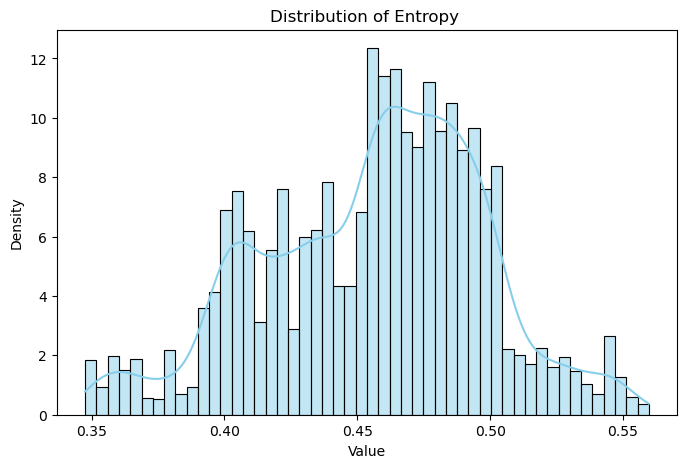

0.36317684321736915 0.5356759997531073


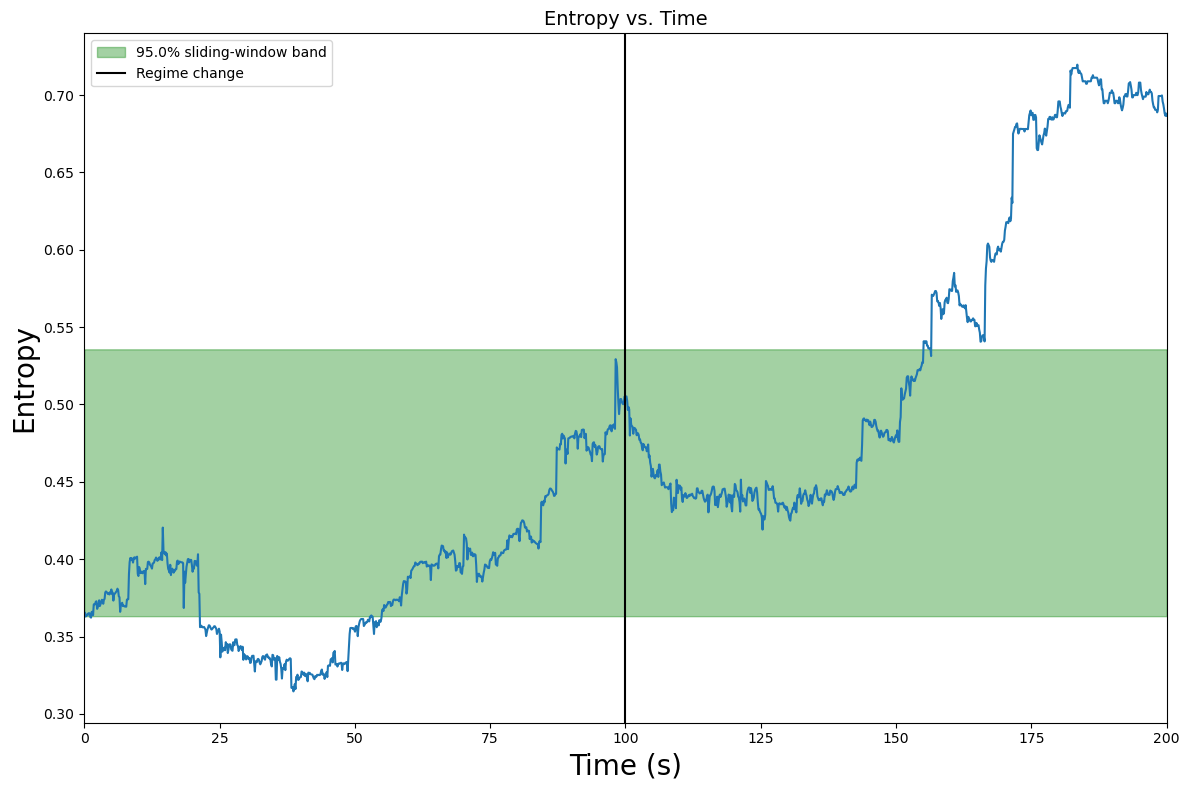

0.05


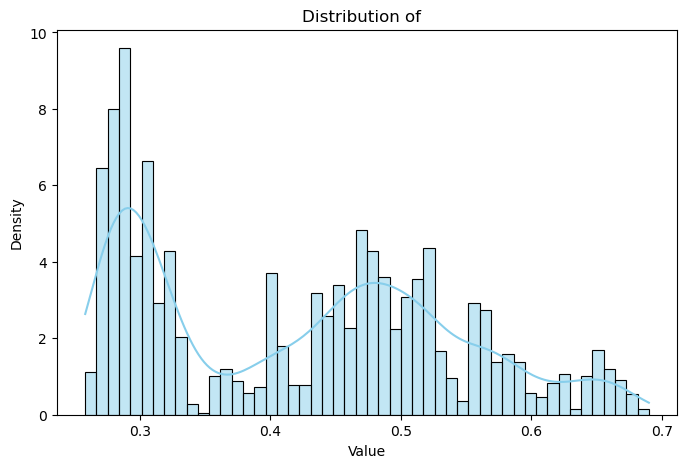

0.2693134449968732 0.6544709387881426


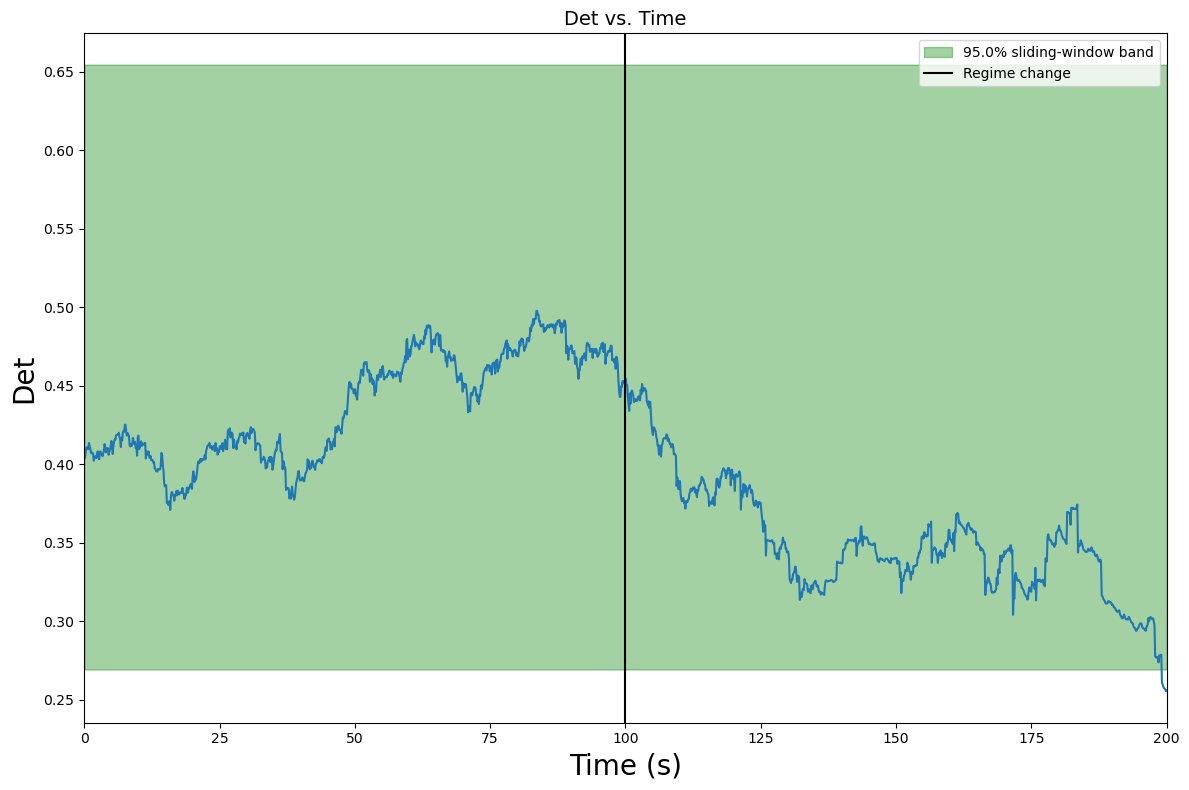

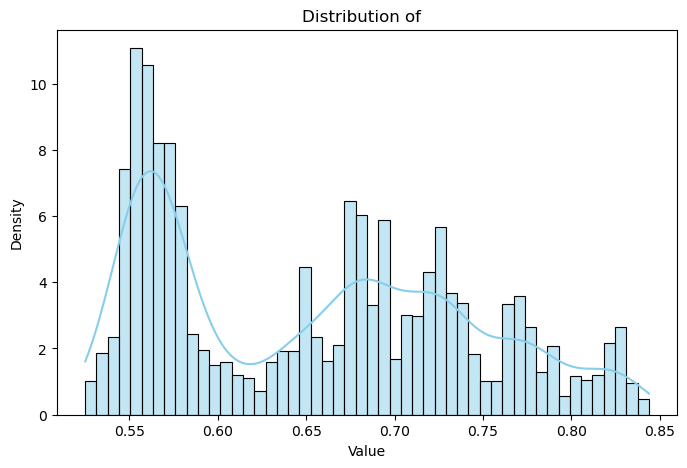

0.5404143977710651 0.8252683575266446


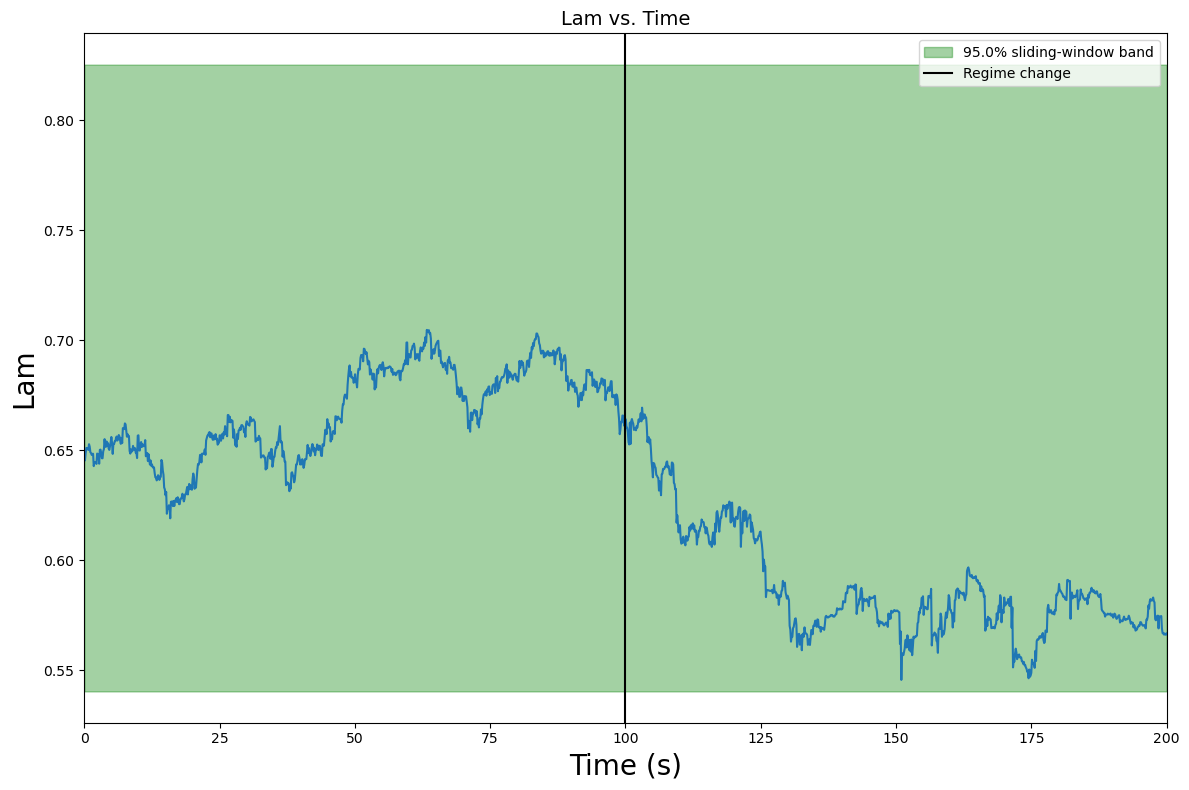

In [24]:
alpha=0.05

lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entropy')
plotting(ENTRS, 'Entropy', lo,hi, alpha*100)
print(alpha)

lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='')
plotting(DETS, 'Det', lo,hi, alpha*100)


lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='')
plotting(LAMS, 'Lam', lo,hi, alpha*100)

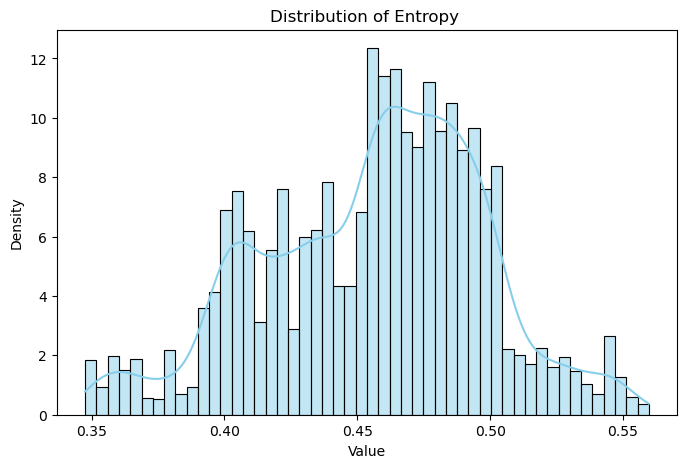

0.38232750803498844 0.5209774743307432


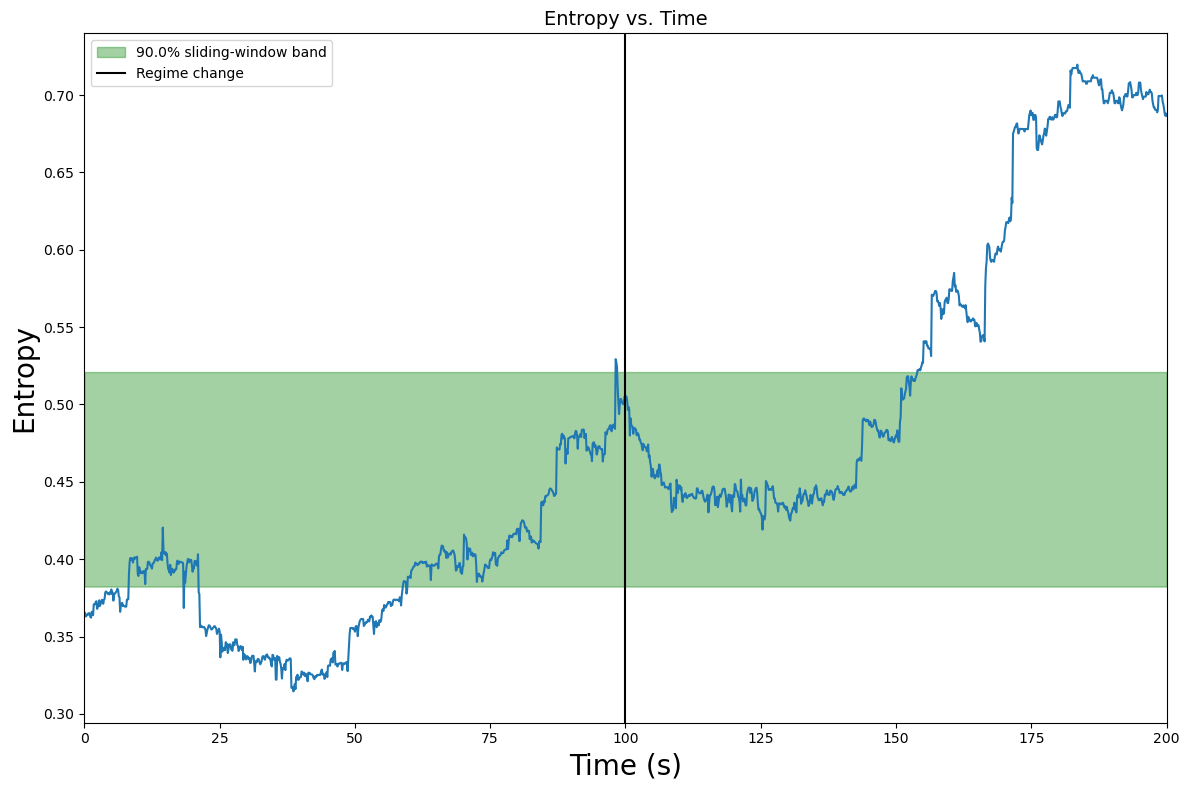

0.1


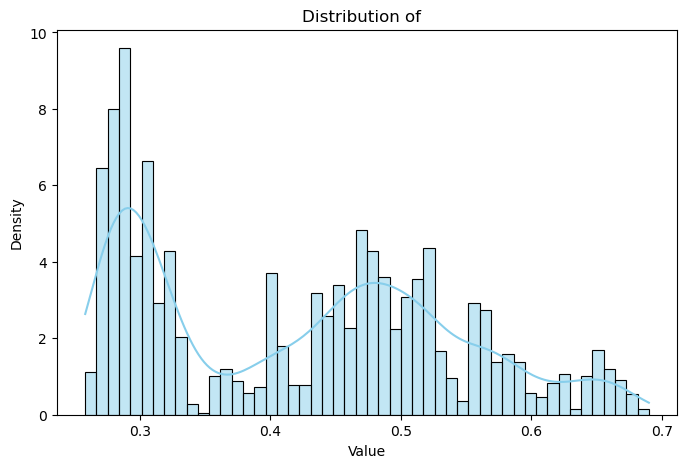

0.27354658542777355 0.6262378422922793


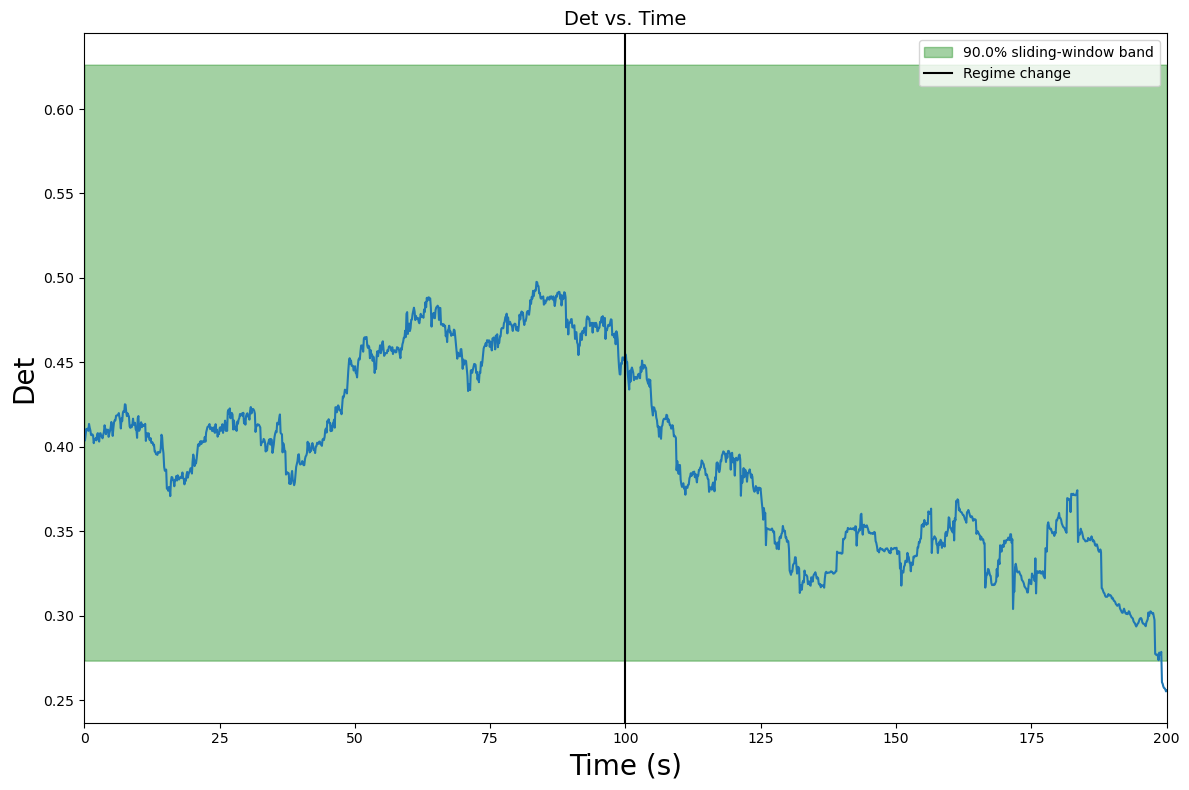

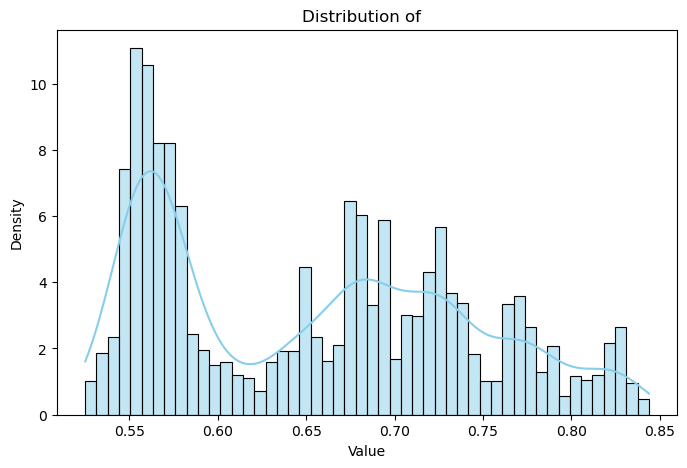

0.5475379049777643 0.8069389322749968


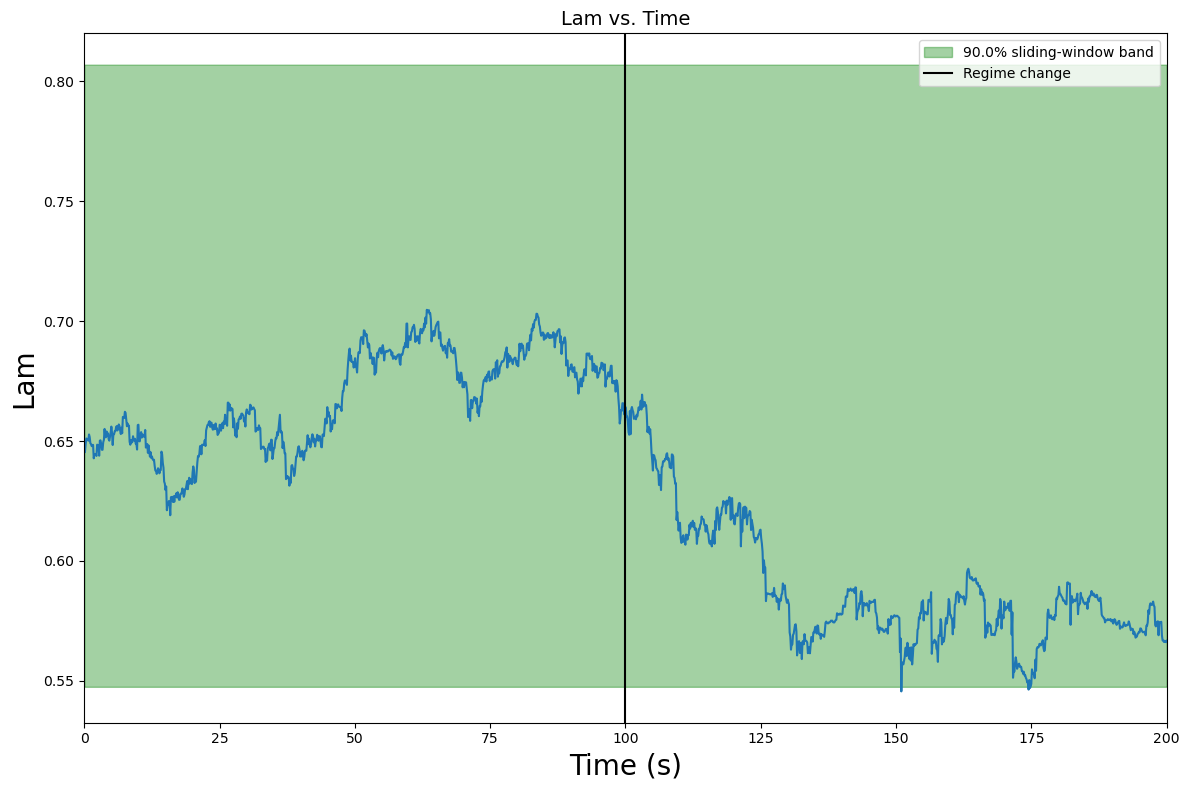

In [25]:
alpha=0.1

lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entropy')
plotting(ENTRS, 'Entropy', lo,hi, alpha*100)
print(alpha)

lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='')
plotting(DETS, 'Det', lo,hi, alpha*100)


lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='')
plotting(LAMS, 'Lam', lo,hi, alpha*100)

In [31]:
sample_percent = .10
sample_amount = int(sample_percent *len(DETS))
print(sample_amount)

def bootstrap_ci(data, statfunc=np.mean, n_boot=2000, alpha=0.05, seed=0):
    rng = np.random.RandomState(seed)
    boots = np.array([statfunc(rng.choice(data, size=len(data), replace=True)) for _ in range(n_boot)])
    est = statfunc(data)
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return est, lo, hi

160


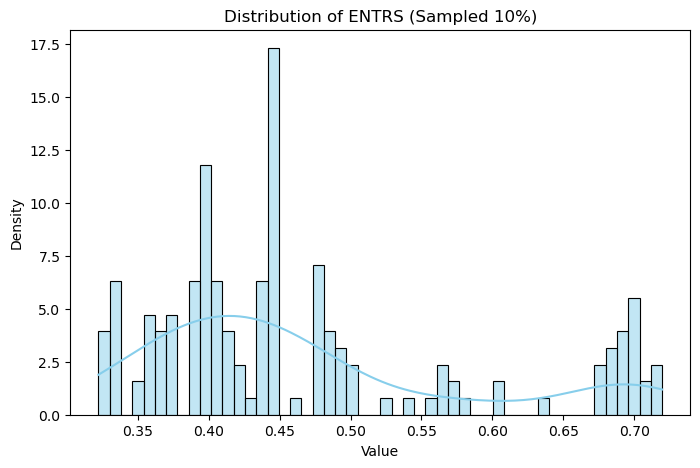

/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Region 0: indices 200:165  (n=0)
Region 0 mean=nan, 95% CI=(nan, nan)
Region 1: indices 166:286  (n=121)
Region 1 mean=0.3447, 95% CI=(0.3426, 0.3471)
Region 2: indices 287:365  (n=79)
Region 2 mean=0.3266, 95% CI=(0.3255, 0.3278)
Region 3: indices 366:501  (n=136)
Region 3 mean=0.3645, 95% CI=(0.3611, 0.3677)
Region 4: indices 502:751  (n=250)
Region 4 mean=0.4232, 95% CI=(0.4194, 0.4269)
Region 5: indices 752:1599  (n=848)
Region 5 mean=0.5403, 95% CI=(0.5335, 0.5474)


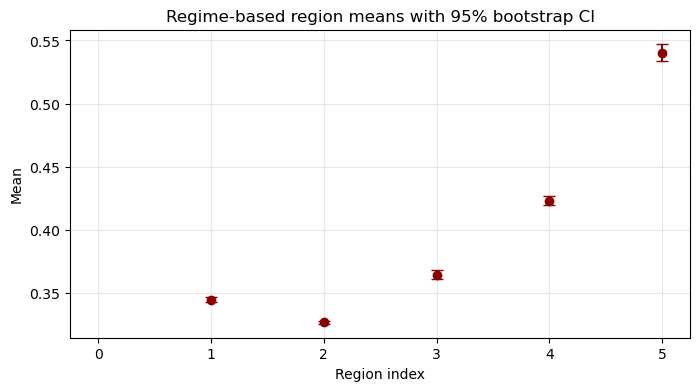

In [32]:
sample = np.random.choice(ENTRS, size=sample_amount, replace=False)
plt.figure(figsize=(8, 5))
sns.histplot(sample, bins=50, kde=True, stat="density", color="skyblue", edgecolor="black")
plt.title(f"Distribution of ENTRS (Sampled {sample_percent*100:.0f}%)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

regime_idxs = np.array([165, 286, 365, 501, 751]).astype(int)

start_of_times = int(times[0])   
N = len(ENTRS)
starts = [start_of_times] + list((regime_idxs + 1).astype(int))
ends   = list(regime_idxs.astype(int)) + [N-1]

segments = list(zip(starts, ends))
regions = [ENTRS[s:e+1] for s, e in segments]

means, lows, highs = [], [], []
for i, (s, e) in enumerate(segments):
    est, lo, hi = bootstrap_ci(regions[i], statfunc=np.mean, n_boot=2000, alpha=0.05, seed=0+i)
    means.append(est)
    lows.append(lo)
    highs.append(hi)
    print(f"Region {i}: indices {s}:{e}  (n={len(regions[i])})")
    print(f"Region {i} mean={est:.4f}, 95% CI=({lo:.4f}, {hi:.4f})")

x = range(len(regions))
err_lower = [m - l for m, l in zip(means, lows)]
err_upper = [h - m for m, h in zip(means, highs)]

plt.figure(figsize=(8, 4))
plt.errorbar(x, means, yerr=[err_lower, err_upper], fmt='o', capsize=4, color="darkred")
plt.xticks(x)
plt.xlabel("Region index")
plt.ylabel("Mean")
plt.title("Regime-based region means with 95% bootstrap CI")
plt.grid(alpha=0.3)
plt.show()

Region 0: indices 0:79  (n=80)
Region 0 mean=0.3767, 95% CI=(0.3743, 0.3793)
Region 1: indices 80:159  (n=80)
Region 1 mean=0.3963, 95% CI=(0.3951, 0.3977)
Region 2: indices 160:239  (n=80)
Region 2 mean=0.3544, 95% CI=(0.3507, 0.3583)
Region 3: indices 240:319  (n=80)
Region 3 mean=0.3317, 95% CI=(0.3302, 0.3331)
Region 4: indices 320:399  (n=80)
Region 4 mean=0.3315, 95% CI=(0.3296, 0.3336)
Region 5: indices 400:479  (n=80)
Region 5 mean=0.3669, 95% CI=(0.3649, 0.3689)
Region 6: indices 480:559  (n=80)
Region 6 mean=0.3981, 95% CI=(0.3971, 0.3992)
Region 7: indices 560:639  (n=80)
Region 7 mean=0.4028, 95% CI=(0.4008, 0.4047)
Region 8: indices 640:719  (n=80)
Region 8 mean=0.4393, 95% CI=(0.4341, 0.4445)
Region 9: indices 720:799  (n=80)
Region 9 mean=0.4827, 95% CI=(0.4798, 0.4858)
Region 10: indices 800:879  (n=80)
Region 10 mean=0.4634, 95% CI=(0.4591, 0.4677)
Region 11: indices 880:959  (n=80)
Region 11 mean=0.4408, 95% CI=(0.4401, 0.4416)
Region 12: indices 960:1039  (n=80)
Regi

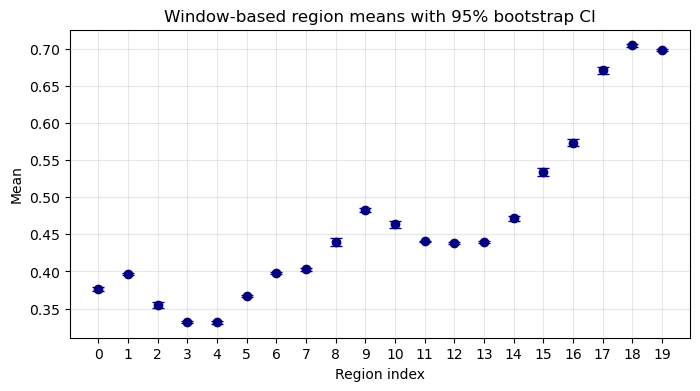

In [33]:
window_size_regions = int(.05 * len(ENTRS))
regions = [ENTRS[i:i+window_size_regions] for i in range(0, len(ENTRS), window_size_regions)]

means, lows, highs = [], [], []
for i, s in enumerate(range(0, len(ENTRS), window_size_regions)):
    e = min(len(ENTRS) - 1, s + window_size_regions - 1)
    est, lo, hi = bootstrap_ci(regions[i], statfunc=np.mean, n_boot=2000, alpha=0.05, seed=0+i)
    means.append(est)
    lows.append(lo)
    highs.append(hi)
    print(f"Region {i}: indices {s}:{e}  (n={len(regions[i])})")
    print(f"Region {i} mean={est:.4f}, 95% CI=({lo:.4f}, {hi:.4f})")

x = range(len(regions))
err_lower = [m - l for m, l in zip(means, lows)]
err_upper = [h - m for m, h in zip(means, highs)]

plt.figure(figsize=(8, 4))
plt.errorbar(x, means, yerr=[err_lower, err_upper], fmt='o', capsize=4, color="navy")
plt.xticks(x)
plt.xlabel("Region index")
plt.ylabel("Mean")
plt.title("Window-based region means with 95% bootstrap CI")
plt.grid(alpha=0.3)
plt.show()


In [34]:
# window_size_regions = int(.1 * len(ENTRS)) regions = [ENTRS[i:i+window_size_regions] for i in range(0, len(ENTRS), window_size_regions)] for i, s in enumerate(range(0, len(ENTRS), window_size_regions)): e = min(len(ENTRS) - 1, s + window_size_regions - 1) print(f"Region {i}: indices {s}:{e} (n={len(regions[i])})") for i, reg in enumerate(regions): est, lo, hi = bootstrap_ci(reg, statfunc=np.mean, n_boot=2000, alpha=0.05, seed=0) print(f"Region {i} mean={est:.4f}, 95% CI=({lo:.4f}, {hi:.4f})")

Region 0: indices 0:79  (n=80)
Region 0 mean=0.3767, 95% CI=(0.3743, 0.3793)
Region 1: indices 7:86  (n=80)
Region 1 mean=0.3791, 95% CI=(0.3767, 0.3818)
Region 2: indices 14:93  (n=80)
Region 2 mean=0.3815, 95% CI=(0.3793, 0.3839)
Region 3: indices 21:100  (n=80)
Region 3 mean=0.3838, 95% CI=(0.3813, 0.3864)
Region 4: indices 28:107  (n=80)
Region 4 mean=0.3862, 95% CI=(0.3836, 0.3886)
Region 5: indices 35:114  (n=80)
Region 5 mean=0.3883, 95% CI=(0.3857, 0.3907)
Region 6: indices 42:121  (n=80)
Region 6 mean=0.3907, 95% CI=(0.3880, 0.3933)
Region 7: indices 49:128  (n=80)
Region 7 mean=0.3922, 95% CI=(0.3897, 0.3947)
Region 8: indices 56:135  (n=80)
Region 8 mean=0.3939, 95% CI=(0.3916, 0.3959)
Region 9: indices 63:142  (n=80)
Region 9 mean=0.3963, 95% CI=(0.3948, 0.3977)
Region 10: indices 70:149  (n=80)
Region 10 mean=0.3966, 95% CI=(0.3952, 0.3979)
Region 11: indices 77:156  (n=80)
Region 11 mean=0.3963, 95% CI=(0.3950, 0.3976)
Region 12: indices 84:163  (n=80)
Region 12 mean=0.39

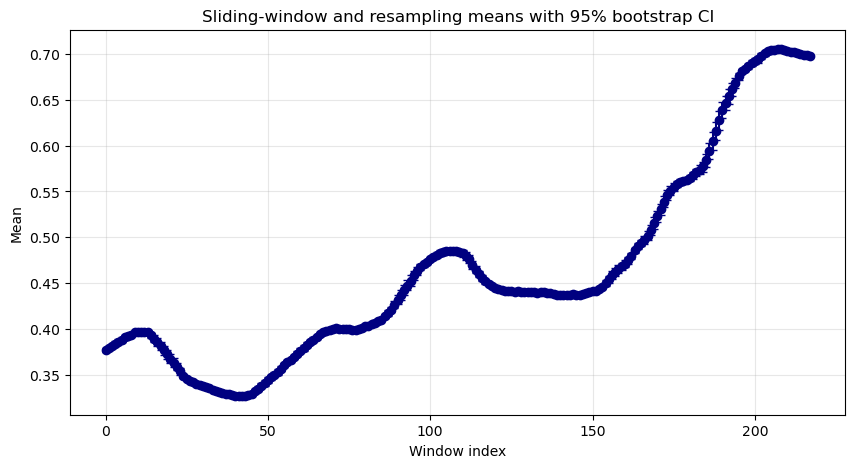

In [35]:
window_size = int(.05 * len(ENTRS))

# pick step size so we get ~50 windows
n_windows_target = 200
step = max(1, (len(ENTRS) - window_size) // n_windows_target)

regions = [ENTRS[i:i+window_size] for i in range(0, len(ENTRS) - window_size + 1, step)]

means, lows, highs = [], [], []
for i, start in enumerate(range(0, len(ENTRS) - window_size + 1, step)):
    s = start
    e = s + window_size - 1
    est, lo, hi = bootstrap_ci(regions[i], statfunc=np.mean, n_boot=2000, alpha=0.05, seed=0+i)
    means.append(est)
    lows.append(lo)
    highs.append(hi)
    print(f"Region {i}: indices {s}:{e}  (n={len(regions[i])})")
    print(f"Region {i} mean={est:.4f}, 95% CI=({lo:.4f}, {hi:.4f})")

# Error bars
x = range(len(regions))
err_lower = [m - l for m, l in zip(means, lows)]
err_upper = [h - m for m, h in zip(means, highs)]

plt.figure(figsize=(10, 5))
plt.errorbar(x, means, yerr=[err_lower, err_upper], fmt='o', capsize=3, color="navy")
plt.xlabel("Window index")
plt.ylabel("Mean")
plt.title("Sliding-window and resampling means with 95% bootstrap CI")
plt.grid(alpha=0.3)
plt.show()


In [36]:
import numpy as np
import matplotlib.pyplot as plt

window_size = int(.05 * len(ENTRS))            # 10% window
n_boot = 2000
alpha95 = 0.05
alpha90 = 0.10

starts = list(range(0, len(ENTRS) - window_size + 1, 1))
n_windows = len(starts)
print("window_size:", window_size, "n_windows:", n_windows)

lo95_list = np.zeros(n_windows)
hi95_list = np.zeros(n_windows)
lo90_list = np.zeros(n_windows)
hi90_list = np.zeros(n_windows)
means_list = np.zeros(n_windows)

for i, s in enumerate(starts):
    e = s + window_size - 1
    region = ENTRS[s:e+1]
    est, lo95, hi95 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha95, seed=1000 + i)
    _, lo90, hi90 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha90, seed=2000 + i)
    means_list[i] = est
    lo95_list[i] = lo95
    hi95_list[i] = hi95
    lo90_list[i] = lo90
    hi90_list[i] = hi90

    if (i + 1) % 200 == 0 or (i + 1) == n_windows:
        print(f"Computed window {i+1}/{n_windows}  (indices {s}:{e})")

N = len(ENTRS)
lower95_sum = np.zeros(N)
upper95_sum = np.zeros(N)
lower90_sum = np.zeros(N)
upper90_sum = np.zeros(N)
counts = np.zeros(N, dtype=int)

for i, s in enumerate(starts):
    e = s + window_size - 1
    lower95_sum[s:e+1] += lo95_list[i]
    upper95_sum[s:e+1] += hi95_list[i]
    lower90_sum[s:e+1] += lo90_list[i]
    upper90_sum[s:e+1] += hi90_list[i]
    counts[s:e+1] += 1

counts_safe = counts.copy().astype(float)
counts_safe[counts_safe == 0] = 1.0

lower95 = lower95_sum / counts_safe
upper95 = upper95_sum / counts_safe
lower90 = lower90_sum / counts_safe
upper90 = upper90_sum / counts_safe

print("counts coverage: min", counts.min(), "max", counts.max(), "mean", counts.mean())



window_size: 80 n_windows: 1521
Computed window 200/1521  (indices 199:278)
Computed window 400/1521  (indices 399:478)
Computed window 600/1521  (indices 599:678)
Computed window 800/1521  (indices 799:878)
Computed window 1000/1521  (indices 999:1078)
Computed window 1200/1521  (indices 1199:1278)
Computed window 1400/1521  (indices 1399:1478)
Computed window 1521/1521  (indices 1520:1599)
counts coverage: min 1 max 80 mean 76.05


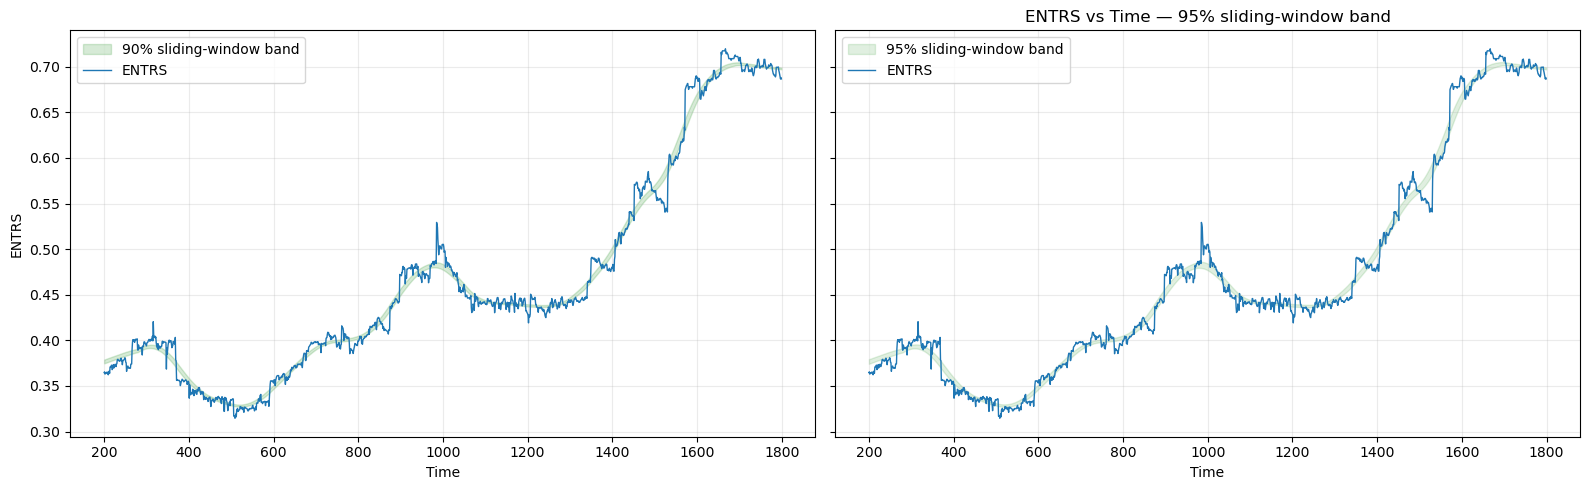

Points outside 90% band: 1346
Points outside 90% band percent : 0.84125
Points outside 95% band: 1290
Points outside 95% band percent : 0.80625


In [37]:
ENTRS = np.asarray(ENTRS)
times_arr = np.asarray(times)   

mask90 = (ENTRS < lower90) | (ENTRS > upper90)
mask95 = (ENTRS < lower95) | (ENTRS > upper95)

idx90 = np.nonzero(mask90)[0].astype(int)
idx95 = np.nonzero(mask95)[0].astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

ax1.fill_between(times_arr, lower90, upper90, alpha=0.16, label='90% sliding-window band', zorder=1, color='green')
ax1.plot(times_arr, ENTRS, linewidth=1, label='ENTRS', zorder=5)
ax1.set_xlabel('Time')
ax1.set_ylabel('ENTRS')
ax1.grid(alpha=0.25)
ax1.legend()

ax2.fill_between(times_arr, lower95, upper95, alpha=0.12, label='95% sliding-window band', zorder=1, color='green')
ax2.plot(times_arr, ENTRS, linewidth=1, label='ENTRS', zorder=5)
ax2.set_title('ENTRS vs Time — 95% sliding-window band')
ax2.set_xlabel('Time')
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Points outside 90% band: {len(idx90)}")

print(f"Points outside 90% band percent : {len(idx90)/ len(ENTRS) }")
print(f"Points outside 95% band: {len(idx95)}")
print(f"Points outside 95% band percent : {len(idx95)/ len(ENTRS) }")



window_size: 80 n_windows: 1521


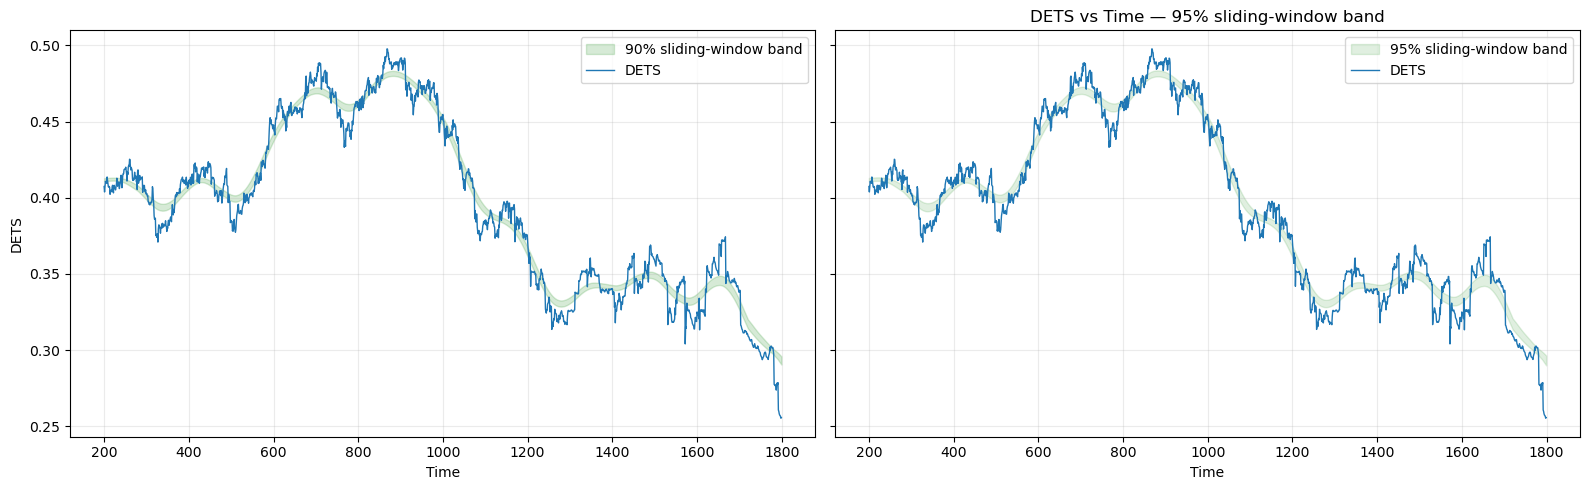

Points outside 90% band: 1380
Points outside 90% band percent : 0.8625
Points outside 95% band: 1340
Points outside 95% band percent : 0.8375


In [38]:
window_size = int(.05 * len(DETS))            # 10% window
n_boot = 2000
alpha95 = 0.05
alpha90 = 0.10

starts = list(range(0, len(DETS) - window_size + 1, 1))
n_windows = len(starts)
print("window_size:", window_size, "n_windows:", n_windows)

lo95_list = np.zeros(n_windows)
hi95_list = np.zeros(n_windows)
lo90_list = np.zeros(n_windows)
hi90_list = np.zeros(n_windows)
means_list = np.zeros(n_windows)

for i, s in enumerate(starts):
    e = s + window_size - 1
    region = DETS[s:e+1]
    est, lo95, hi95 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha95, seed=1000 + i)
    _, lo90, hi90 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha90, seed=2000 + i)
    means_list[i] = est
    lo95_list[i] = lo95
    hi95_list[i] = hi95
    lo90_list[i] = lo90
    hi90_list[i] = hi90


N = len(DETS)
lower95_sum = np.zeros(N)
upper95_sum = np.zeros(N)
lower90_sum = np.zeros(N)
upper90_sum = np.zeros(N)
counts = np.zeros(N, dtype=int)

for i, s in enumerate(starts):
    e = s + window_size - 1
    lower95_sum[s:e+1] += lo95_list[i]
    upper95_sum[s:e+1] += hi95_list[i]
    lower90_sum[s:e+1] += lo90_list[i]
    upper90_sum[s:e+1] += hi90_list[i]
    counts[s:e+1] += 1


counts_safe = counts.copy().astype(float)
counts_safe[counts_safe == 0] = 1.0

lower95 = lower95_sum / counts_safe
upper95 = upper95_sum / counts_safe
lower90 = lower90_sum / counts_safe
upper90 = upper90_sum / counts_safe


DETS = np.asarray(DETS)
times_arr = np.asarray(times)   

mask90 = (DETS < lower90) | (DETS > upper90)
mask95 = (DETS < lower95) | (DETS > upper95)

idx90 = np.nonzero(mask90)[0].astype(int)
idx95 = np.nonzero(mask95)[0].astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# 90% plot
ax1.fill_between(times_arr, lower90, upper90, alpha=0.16, label='90% sliding-window band', zorder=1, color='green')
ax1.plot(times_arr, DETS, linewidth=1, label='DETS', zorder=5)
ax1.set_xlabel('Time')
ax1.set_ylabel('DETS')
ax1.grid(alpha=0.25)
ax1.legend()

# 95% plot
ax2.fill_between(times_arr, lower95, upper95, alpha=0.12, label='95% sliding-window band', zorder=1, color='green')
ax2.plot(times_arr, DETS, linewidth=1, label='DETS', zorder=5)
ax2.set_title('DETS vs Time — 95% sliding-window band')
ax2.set_xlabel('Time')
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Points outside 90% band: {len(idx90)}")

print(f"Points outside 90% band percent : {len(idx90)/ len(DETS) }")
print(f"Points outside 95% band: {len(idx95)}")
print(f"Points outside 95% band percent : {len(idx95)/ len(DETS) }")



window_size: 80 n_windows: 1521
Computed window 200/1521  (indices 199:278)
Computed window 400/1521  (indices 399:478)
Computed window 600/1521  (indices 599:678)
Computed window 800/1521  (indices 799:878)
Computed window 1400/1521  (indices 1399:1478)
Computed window 1521/1521  (indices 1520:1599)
counts coverage: min 1 max 80 mean 76.05


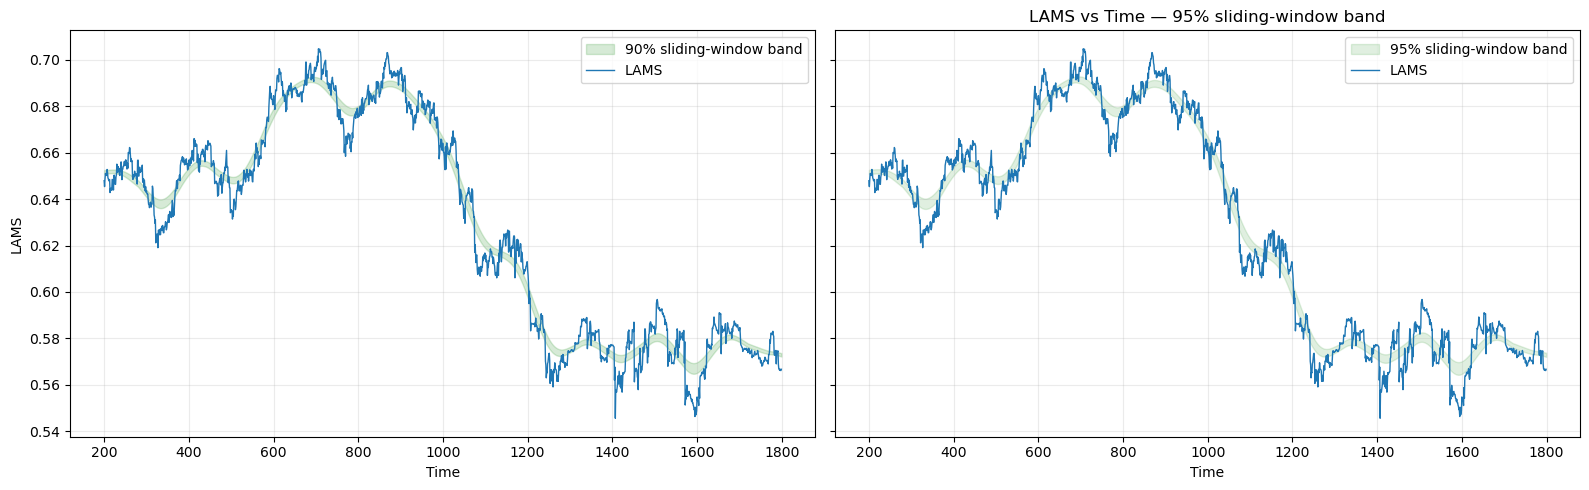

Points outside 90% band: 1391
Points outside 90% band percent : 0.869375
Points outside 95% band: 1354
Points outside 95% band percent : 0.84625


In [39]:
window_size = int(.05 * len(LAMS))            # 10% window
n_boot = 2000
alpha95 = 0.05
alpha90 = 0.10

# sliding windows: one for every start (step=1) so we have maximum resolution
starts = list(range(0, len(LAMS) - window_size + 1, 1))
n_windows = len(starts)
print("window_size:", window_size, "n_windows:", n_windows)

# store per-window endpoints
lo95_list = np.zeros(n_windows)
hi95_list = np.zeros(n_windows)
lo90_list = np.zeros(n_windows)
hi90_list = np.zeros(n_windows)
means_list = np.zeros(n_windows)

for i, s in enumerate(starts):
    e = s + window_size - 1
    region = LAMS[s:e+1]
    est, lo95, hi95 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha95, seed=1000 + i)
    _, lo90, hi90 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha90, seed=2000 + i)
    means_list[i] = est
    lo95_list[i] = lo95
    hi95_list[i] = hi95
    lo90_list[i] = lo90
    hi90_list[i] = hi90

    # lightweight progress print
    if (i + 1) % 200 == 0 or (i + 1) == n_windows:
        print(f"Computed window {i+1}/{n_windows}  (indices {s}:{e})")

# Build per-index (time-point) bands by aggregating endpoints from all windows that include the index
N = len(LAMS)
lower95_sum = np.zeros(N)
upper95_sum = np.zeros(N)
lower90_sum = np.zeros(N)
upper90_sum = np.zeros(N)
counts = np.zeros(N, dtype=int)

for i, s in enumerate(starts):
    e = s + window_size - 1
    # add scalar window endpoints into full slice
    lower95_sum[s:e+1] += lo95_list[i]
    upper95_sum[s:e+1] += hi95_list[i]
    lower90_sum[s:e+1] += lo90_list[i]
    upper90_sum[s:e+1] += hi90_list[i]
    counts[s:e+1] += 1

# safety: if any index not covered (counts==0) set count to 1 to avoid div-by-zero
# but with starts covering 0..N-window_size this should not happen
counts_safe = counts.copy().astype(float)
counts_safe[counts_safe == 0] = 1.0

lower95 = lower95_sum / counts_safe
upper95 = upper95_sum / counts_safe
lower90 = lower90_sum / counts_safe
upper90 = upper90_sum / counts_safe

print("counts coverage: min", counts.min(), "max", counts.max(), "mean", counts.mean())



LAMS = np.asarray(LAMS)
times_arr = np.asarray(times)   # or np.asarray(TIME)

# masks & indices
mask90 = (LAMS < lower90) | (LAMS > upper90)
mask95 = (LAMS < lower95) | (LAMS > upper95)

idx90 = np.nonzero(mask90)[0].astype(int)
idx95 = np.nonzero(mask95)[0].astype(int)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# 90% plot
ax1.fill_between(times_arr, lower90, upper90, alpha=0.16, label='90% sliding-window band', zorder=1, color='green')
ax1.plot(times_arr, LAMS, linewidth=1, label='LAMS', zorder=5)
ax1.set_xlabel('Time')
ax1.set_ylabel('LAMS')
ax1.grid(alpha=0.25)
ax1.legend()

# 95% plot
ax2.fill_between(times_arr, lower95, upper95, alpha=0.12, label='95% sliding-window band', zorder=1, color='green')
ax2.plot(times_arr, LAMS, linewidth=1, label='LAMS', zorder=5)
ax2.set_title('LAMS vs Time — 95% sliding-window band')
ax2.set_xlabel('Time')
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

# quick summary prints
print(f"Points outside 90% band: {len(idx90)}")

print(f"Points outside 90% band percent : {len(idx90)/ len(LAMS) }")
print(f"Points outside 95% band: {len(idx95)}")
print(f"Points outside 95% band percent : {len(idx95)/ len(LAMS) }")


## 